---
title: "Answers"
subtitle: "Hints/answers to selected exercises"
format:
  html: default
  pdf: default
---

I strongly encourage you to try the exercises for yourself first. I'll release my solutions or some hints around a week after the lecture.

## Lecture 1

@exr-e

In [1]:
e = exp(1)

N = 1:100;
err = @. abs( e- (1 + 1/N)^N );

Error = abs error (in this case)

In [2]:
err[1:10]

10-element Vector{Float64}:
 0.7182818284590451
 0.4682818284590451
 0.34791145808867485
 0.2768755784590451
 0.22996182845904567
 0.19665545671693163
 0.17178213141833298
 0.1524973145086972
 0.13710703674584712
 0.12453936835904278

Relative error

In [3]:
err[1:10]/e

10-element Vector{Float64}:
 0.26424111765711533
 0.17227125736425472
 0.12798947277880338
 0.10185683307753335
 0.08459822894427681
 0.07234549952033957
 0.0631951145094156
 0.05610062684160521
 0.05043886005873465
 0.045815473235769066

Number of correct digits:

In [4]:
η = - log10.( err[1:10]/exp(1) )

10-element Vector{Float64}:
 0.5779996023832055
 0.7637871764659977
 0.8928257498997241
 0.992009830990522
 1.072638728778693
 1.1405884803607715
 1.199316494876063
 1.2510322861176486
 1.2972347372416126
 1.338987823174671

Rate of convergence:

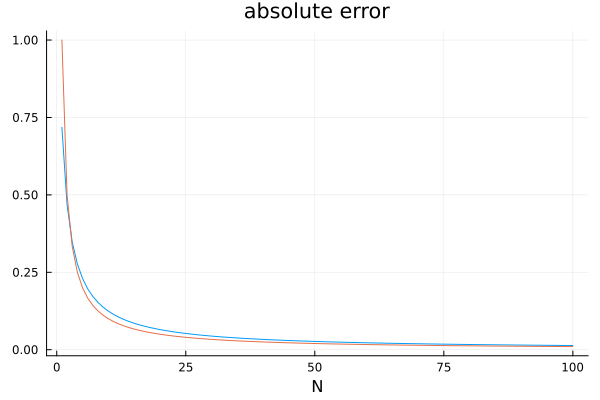

In [ ]:
using Plots, LaTeXStrings
plot( err , xlabel="N", title="absolute error", legend=false)
plot!( N.^(-1) )

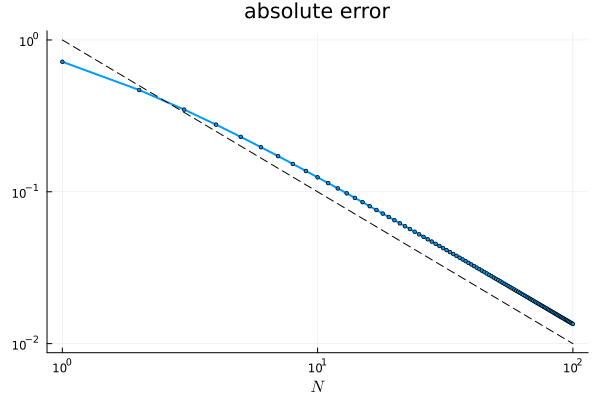

In [6]:
plot( err ;
    xaxis=:log, yaxis=:log, xlabel=L"N", title="absolute error", legend=false, lw=2, m=2 )
plot!( N.^(-1), color=:black, linestyle=:dash, label = L"n^{-1}" )

@exr-Euler-Mascheroni

In [7]:
γ = Base.MathConstants.eulergamma

γ = 0.5772156649015...

In [8]:
Nmax = 1000;

N = 1:Nmax;
γN = zeros( Nmax );
γN[1] = 1;
for n ∈ 2:Nmax
    γN[n] = (1/n) + γN[n-1] + log( (n-1)/n );
end

println( "gamma[1000] = ", γN[1000] )
println( "Abs. error = " , abs( γ - γN[1000] ) )

gamma[1000] = 0.5777155815682078
Abs. error = 0.0004999166666749266


Number of accurate digits:

In [9]:
η = - log10.( abs( γ - γN[1000] )/ γ ) 

3.0624404928861617

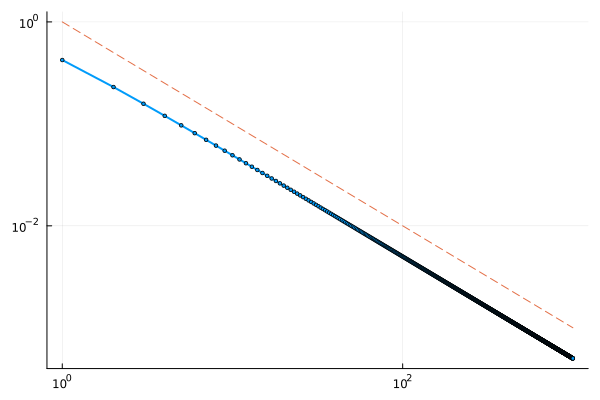

In [10]:
plot( γN .- γ , xaxis=:log, yaxis=:log , legend = false, lw = 2, m=2)   
plot!( N.^(-1) , linestyle=:dash)

*Proof.* First, notice that 

\begin{align}   
    \gamma_n - \gamma_N 
    %
    &= \log \frac Nn - \sum_{k=n+1}^N \frac{1}{k}\\
    %
    &= \sum_{k=n+1}^N \left( \log \frac{k}{k-1} - \frac{1}{k} \right).
\end{align}

Here, $\frac1k$ is the area under the rectangle with base $[k-1,k]$ and height $\frac1k$ and $\log \frac{k}{k-1}$ is the integral of $\frac1x$ between $x = k-1$ and $x = k$: 

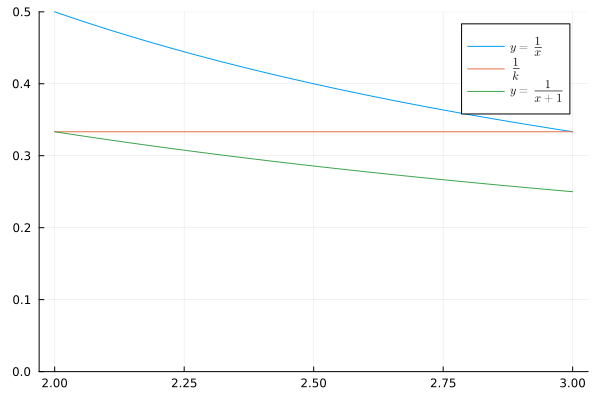

In [11]:
k=3; x = range(k-1,k, 100);
plot( x, [x.^(-1) ones(100)./k (x .+ 1).^(-1)], 
    ylims=(0,1/(k-1)), 
    label=[L"y=\frac{1}{x}" L"\frac{1}{k}" L"y=\frac{1}{x+1}"] )

In the graph above, $\frac1k$ is the area under the red line, $\log \frac{k}{k-1}$ is the area under the blue line. We upper bound the absolute value of the error between these areas, by computing the area between $y = \frac1x$ and $y=\frac1{x+1}$:

\begin{align}
    0 \leq \gamma_n - \gamma_N 
    %
    &\leq \sum_{k=n+1}^N \left( \log \frac{k}{k-1} - \frac{1}{k} \right) \\
    %
    &\leq \sum_{k=n+1}^N \int_{k-1}^k \left( \frac{1}{x} - \frac{1}{x + 1} \right) \mathrm{d}x 
    %
    = \int_{n}^\infty \frac{1}{x(x+1)} \mathrm{d}x \\
    %
    &\leq \int_{n}^\infty \frac{1}{x^2} \mathrm{d}x = \frac1n
\end{align}

Here, we have shown that $(\gamma_n)$ is a Cauchy sequence and thus it converges, and we have the same estimate for $\gamma_n - \gamma$ by taking the limit in $N$. $\text{    }\square$ 